# Tesla Deliveries ML Project
### Dataset: Tesla EA Deliveries and Production Data 2015-2025


## Step 0 — Install and Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("All imports worked!")


All imports worked!


## Step 1 — Load the Real Dataset



In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(f'Shape: {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)')
print()
print('Columns:', list(df.columns))


Shape: (2640, 12)  (2640 rows, 12 columns)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [5]:
print('Regions:', df['Region'].unique())
print('Models: ', df['Model'].unique())
print('Source: ', df['Source_Type'].unique())
print('Year range:', df['Year'].min(), 'to', df['Year'].max())


Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Models:  ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Source:  ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']
Year range: 2015 to 2025


## Step 2 — Check and Clean the Data


In [6]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing: 0


In [7]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')


Duplicate rows: 0


In [9]:
# IQR outlier check on our target column
Q1  = df['Estimated_Deliveries'].quantile(0.25)
Q3  = df['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Estimated_Deliveries'] < lower) | (df['Estimated_Deliveries'] > upper)]
print(f'Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}')
print(f'Outlier bounds: below {lower:,.0f} or above {upper:,.0f}')
print(f'Outlier rows found: {len(outliers)}')


Q1=7,292  Q3=12,510  IQR=5,218
Outlier bounds: below -535 or above 20,338
Outlier rows found: 12


In [10]:
df_clean = df.copy()
print("Dataset is clean and ready!")


Dataset is clean and ready!


## Step 3 — Explore the Data (EDA)


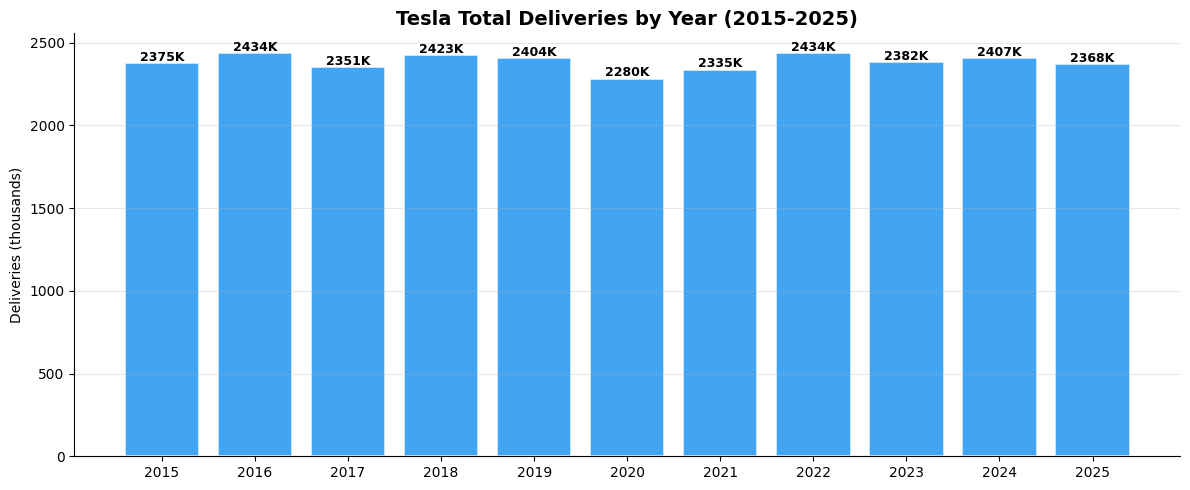

In [11]:
# Chart 1: Total deliveries by year
yearly = df_clean.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1000,
              color='#2196F3', alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, yearly['Estimated_Deliveries'] / 1000):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:.0f}K', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Tesla Total Deliveries by Year (2015-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Deliveries (thousands)')
ax.set_xticks(yearly['Year'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


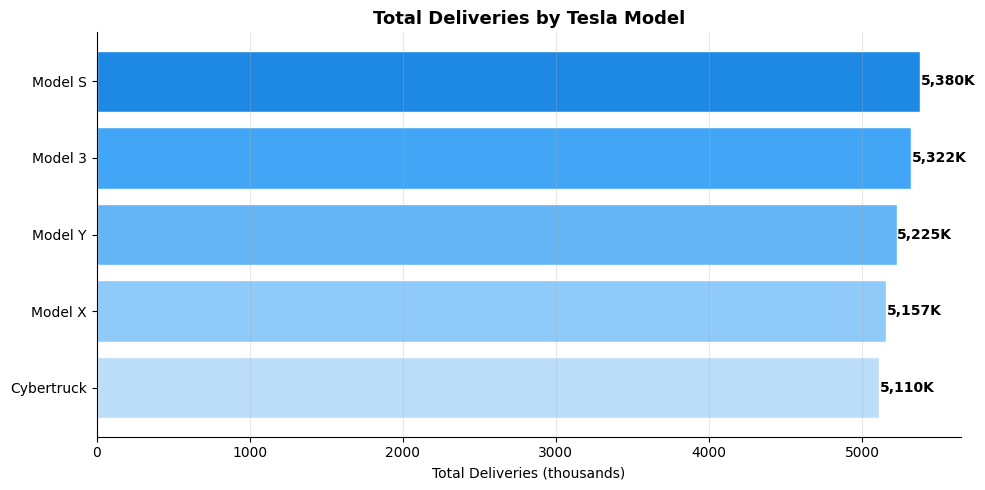

In [12]:
# Chart 2: Deliveries by model
by_model = df_clean.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#BBDEFB','#90CAF9','#64B5F6','#42A5F5','#1E88E5']
bars = ax.barh(by_model.index, by_model.values / 1000,
               color=colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, by_model.values / 1000):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}K', va='center', fontsize=10, fontweight='bold')
ax.set_title('Total Deliveries by Tesla Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Deliveries (thousands)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


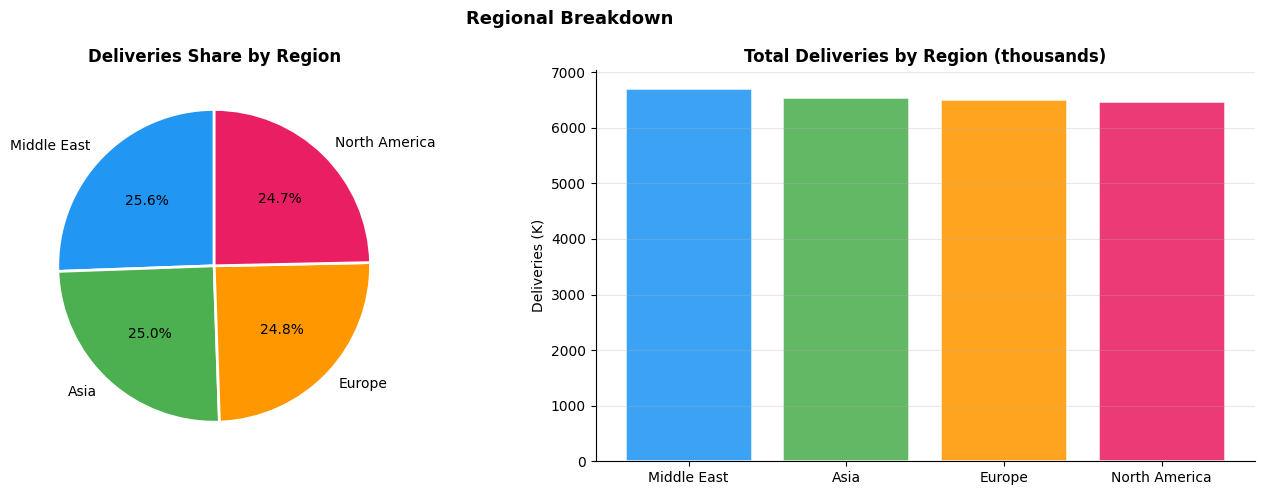

In [13]:
# Chart 3: Deliveries by region
by_region = df_clean.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
axes[0].pie(by_region.values, labels=by_region.index, autopct='%1.1f%%',
            startangle=90, colors=reg_colors,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Deliveries Share by Region', fontweight='bold')
axes[1].bar(by_region.index, by_region.values / 1000,
            color=reg_colors, edgecolor='white', linewidth=1.2, alpha=0.88)
axes[1].set_title('Total Deliveries by Region (thousands)', fontweight='bold')
axes[1].set_ylabel('Deliveries (K)')
axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('Regional Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


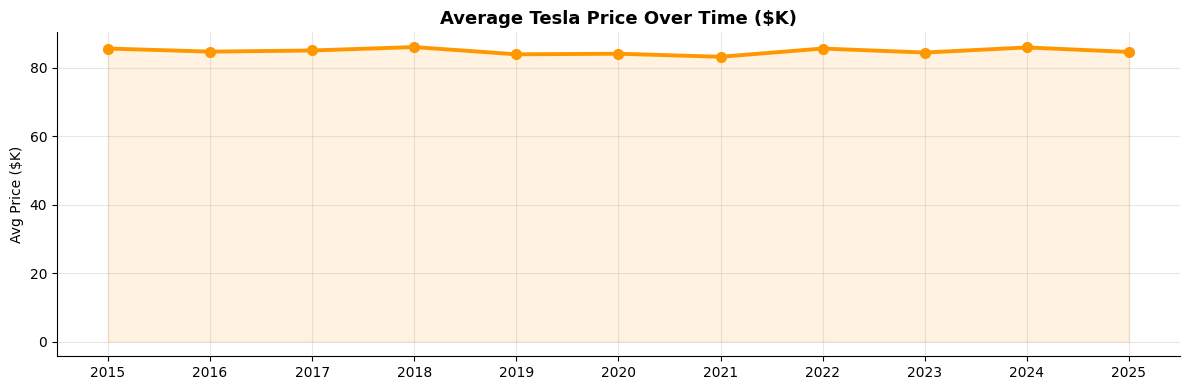

Prices dropped from ~$90K to ~$55K after 2022 — Tesla cut prices to stay competitive!


In [14]:
# Chart 4: Average price over time
avg_price_yr = df_clean.groupby('Year')['Avg_Price_USD'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(avg_price_yr['Year'], avg_price_yr['Avg_Price_USD'] / 1000,
        color='#FF9800', linewidth=2.8, marker='o', markersize=7)
ax.fill_between(avg_price_yr['Year'], avg_price_yr['Avg_Price_USD'] / 1000,
                alpha=0.12, color='#FF9800')
ax.set_title('Average Tesla Price Over Time ($K)', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Price ($K)')
ax.set_xticks(avg_price_yr['Year'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Prices dropped from ~$90K to ~$55K after 2022 — Tesla cut prices to stay competitive!")


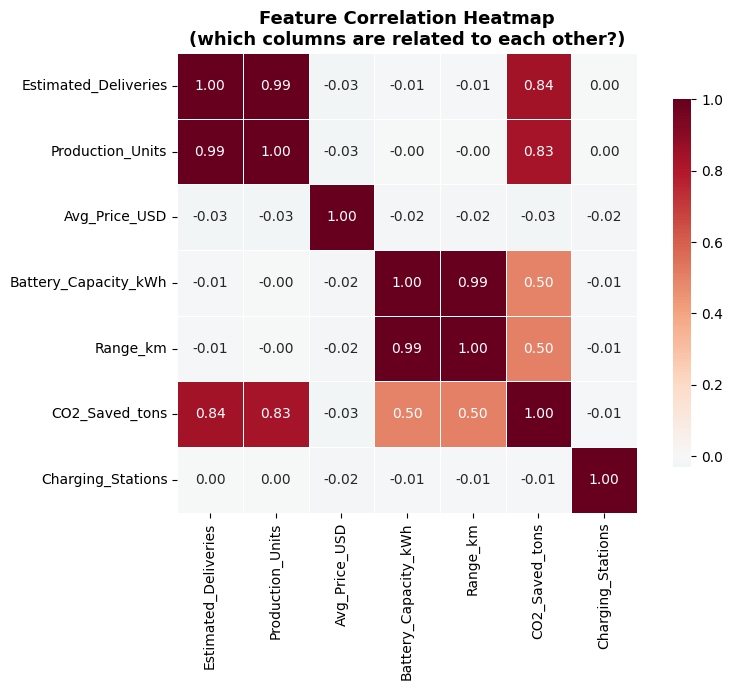

CO2_Saved_tons and Estimated_Deliveries are strongly correlated — more EVs = more CO2 saved!


In [15]:
# Chart 5: Correlation heatmap
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap\n(which columns are related to each other?)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("CO2_Saved_tons and Estimated_Deliveries are strongly correlated — more EVs = more CO2 saved!")


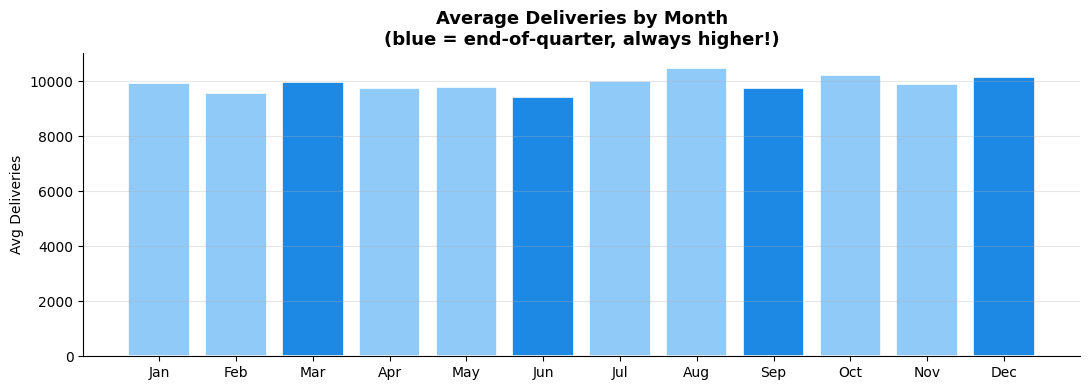

March, June, September, December are always Tesla's strongest months!


In [16]:
# Chart 6: Monthly delivery pattern — which month is strongest?
monthly_avg = df_clean.groupby('Month')['Estimated_Deliveries'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 4))
# Highlight end-of-quarter months (3, 6, 9, 12)
bar_colors = ['#1E88E5' if m in [3,6,9,12] else '#90CAF9' for m in range(1,13)]
ax.bar(month_names, monthly_avg.values, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_title('Average Deliveries by Month\n(blue = end-of-quarter, always higher!)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Avg Deliveries')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("March, June, September, December are always Tesla's strongest months!")


## Step 4 — Feature Engineering


In [16]:
df_feat = df_clean.copy()

# ENCODE TEXT COLUMNS into numbers
# LabelEncoder: gives each unique text value a number
# Europe=0, Asia=1, North America=2, Middle East=3 (example)
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df_feat['Region_enc'] = le_region.fit_transform(df_feat['Region'])
df_feat['Model_enc']  = le_model.fit_transform(df_feat['Model'])
df_feat['Source_enc'] = le_source.fit_transform(df_feat['Source_Type'])

print('Region encoding:')
for name, num in zip(le_region.classes_, range(len(le_region.classes_))):
    print(f'  {name} -> {num}')
print()
print('Model encoding:')
for name, num in zip(le_model.classes_, range(len(le_model.classes_))):
    print(f'  {name} -> {num}')


Region encoding:
  Asia -> 0
  Europe -> 1
  Middle East -> 2
  North America -> 3

Model encoding:
  Cybertruck -> 0
  Model 3 -> 1
  Model S -> 2
  Model X -> 3
  Model Y -> 4


In [17]:
# CREATE NEW FEATURES from existing columns

# Which quarter? Month 1/2/3 = Q1, 4/5/6 = Q2, etc.
df_feat['Quarter'] = ((df_feat['Month'] - 1) // 3) + 1

# End-of-quarter flag: months 3, 6, 9, 12 are Tesla's strongest
df_feat['is_end_of_quarter'] = df_feat['Month'].isin([3, 6, 9, 12]).astype(int)

# Price per km of range — value/efficiency ratio
df_feat['price_per_km'] = df_feat['Avg_Price_USD'] / df_feat['Range_km']

print('New columns added:')
new_cols = ['Region_enc','Model_enc','Source_enc','Quarter','is_end_of_quarter','price_per_km']
for c in new_cols:
    print(f'  + {c}')
print()
df_feat[['Month','Quarter','is_end_of_quarter']].drop_duplicates().sort_values('Month')


New columns added:
  + Region_enc
  + Model_enc
  + Source_enc
  + Quarter
  + is_end_of_quarter
  + price_per_km



,Month,Quarter,is_end_of_quarter
2,1,1,0
1,2,1,0
9,3,1,1
5,4,2,0
0,5,2,0
7,6,2,1
17,7,3,0
37,8,3,0
21,9,3,1
12,10,4,0


## Step 5 — Prepare Data for ML

1. Pick which columns are **inputs (features)** and which is the **target (what to predict)**
2. Split into **training set** and **test set**
3. **Scale** so all features are the same size range


In [18]:
TARGET = 'Estimated_Deliveries'  # what we want to predict

# Remove target + columns that would cheat (calculated from target)
REMOVE = [TARGET, 'Region', 'Model', 'Source_Type']

feature_cols = [c for c in df_feat.columns
                if c not in REMOVE and df_feat[c].dtype != 'object']

print('Predicting:', TARGET)
print()
print('Input features:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2}. {col}')
print(f'\nTotal: {len(feature_cols)} features')


Predicting: Estimated_Deliveries

Input features:
   1. Year
   2. Month
   3. Production_Units
   4. Avg_Price_USD
   5. Battery_Capacity_kWh
   6. Range_km
   7. CO2_Saved_tons
   8. Charging_Stations
   9. Region_enc
  10. Model_enc
  11. Source_enc
  12. Quarter
  13. is_end_of_quarter
  14. price_per_km

Total: 14 features


In [19]:
X = df_feat[feature_cols]
y = df_feat[TARGET]

# Split: 80% train, 20% test
# random_state=42 means same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing set:   {len(X_test):,} rows   ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Model LEARNS from training data, then we TEST on data it has never seen!')


Training set:  2,112 rows  (80%)
Testing set:   528 rows   (20%)

Model LEARNS from training data, then we TEST on data it has never seen!


In [20]:
# Scale features — make all numbers roughly the same range
# Important because Avg_Price_USD is 80,000 but Quarter is just 1-4
# Without scaling, model might focus too much on big numbers

scaler = StandardScaler()

# fit ONLY on training data — never fit on test data (that would be cheating!)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)   # just transform, no fitting

print("Scaling done!")
print(f"Before: Avg_Price_USD mean = {X_train['Avg_Price_USD'].mean():,.0f}")
print(f"After:  Avg_Price_USD mean = {X_train_sc[:, feature_cols.index('Avg_Price_USD')].mean():.4f}  (should be ~0)")


Scaling done!
Before: Avg_Price_USD mean = 85,023
After:  Avg_Price_USD mean = 0.0000  (should be ~0)


## Step 6 — Train Linear Regression

It learns a formula like:
> Deliveries = (w1 x Year) + (w2 x Price) + (w3 x Region) + ... + constant

The model figures out the best weights automatically!


In [22]:
# Train the model
model = LinearRegression()
model.fit(X_train_sc, y_train)

print("Model trained!")
print()

Model trained!



## Step 7 — Evaluate the Model


| Metric | Meaning | Better when... |
|--------|---------|----------------|
| **R squared** | % of variation explained | Closer to 1.0 |
| **MAE** | Average prediction error (in cars) | Lower |
| **RMSE** | Like MAE but punishes big errors more | Lower |


In [23]:
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 45)
print("  Linear Regression Results")
print("=" * 45)
print(f'  R^2  = {r2:.4f}  -> explains {r2*100:.1f}% of variation')
print(f'  MAE  = {mae:,.0f} cars  (avg error per prediction)')
print(f'  RMSE = {rmse:,.0f} cars')
print("=" * 45)


  Linear Regression Results
  R^2  = 0.9901  -> explains 99.0% of variation
  MAE  = 310 cars  (avg error per prediction)
  RMSE = 384 cars


In [24]:
# Cross-validation — more honest score using 5 different splits
cv_r2 = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2')

print('Cross-validation R^2 scores (5 folds):')
for i, score in enumerate(cv_r2, 1):
    bar = '#' * int(max(score, 0) * 25)
    print(f'  Fold {i}: {score:.4f}  {bar}')
print(f'\n  Average CV R^2: {cv_r2.mean():.4f}')
print(f'  Std deviation:  {cv_r2.std():.4f}  (lower = more consistent)')


Cross-validation R^2 scores (5 folds):
  Fold 1: 0.9906  ########################
  Fold 2: 0.9905  ########################
  Fold 3: 0.9901  ########################
  Fold 4: 0.9896  ########################
  Fold 5: 0.9906  ########################

  Average CV R^2: 0.9903
  Std deviation:  0.0004  (lower = more consistent)


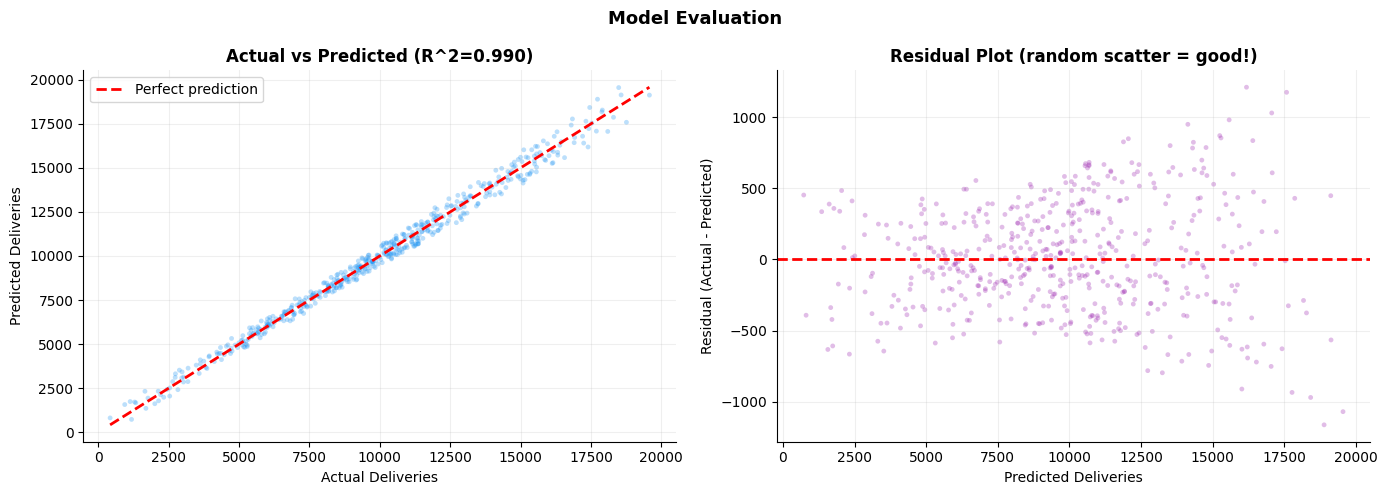

In [25]:
# Visual: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter — dots should be close to the diagonal line
axes[0].scatter(y_test, y_pred, alpha=0.3, s=12, color='#2196F3', edgecolors='none')
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
axes[0].set_title(f'Actual vs Predicted (R^2={r2:.3f})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Residuals — errors should be random around 0
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=12, color='#9C27B0', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Deliveries')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot (random scatter = good!)', fontweight='bold')
axes[1].grid(alpha=0.2)

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


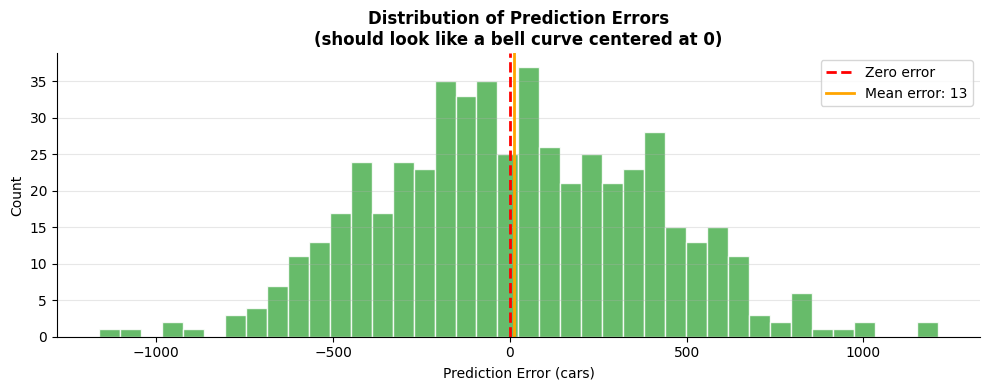

In [26]:
# Distribution of errors
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals, bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(residuals.mean(), color='orange', linestyle='-', linewidth=2,
           label=f'Mean error: {residuals.mean():.0f}')
ax.set_xlabel('Prediction Error (cars)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Prediction Errors\n(should look like a bell curve centered at 0)',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Step 8 — Time Series Forecasting

Let's look at the total delivery trend over time and forecast the next 12 months!

I will use **Exponential Smoothing** — a classic simple method that gives more weight to recent data.


In [27]:
# Aggregate to monthly totals across all regions and models
monthly_total = (
    df_clean
    .groupby(['Year','Month'])['Estimated_Deliveries']
    .sum()
    .reset_index()
)

# Create proper date column
monthly_total['Date'] = pd.to_datetime(
    monthly_total['Year'].astype(str) + '-' +
    monthly_total['Month'].astype(str).str.zfill(2) + '-01'
)
monthly_total = monthly_total.sort_values('Date').set_index('Date')

print(f'Monthly time series: {len(monthly_total)} months')
print(f'From {monthly_total.index[0].date()} to {monthly_total.index[-1].date()}')


Monthly time series: 132 months
From 2015-01-01 to 2025-12-01


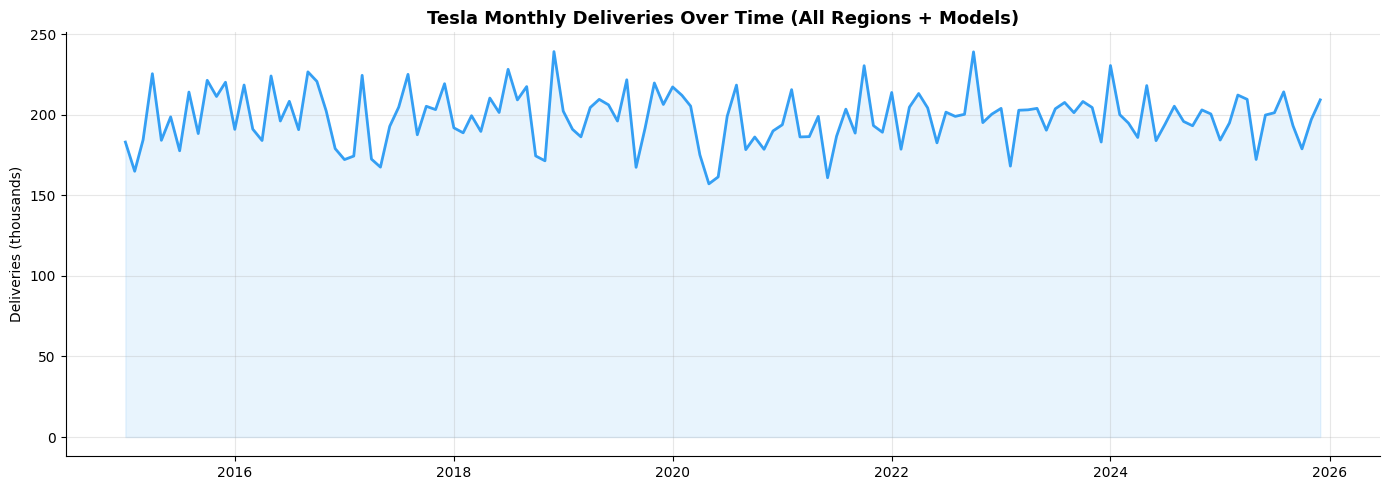

In [28]:
# Plot the historical trend
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_total.index, monthly_total['Estimated_Deliveries'] / 1000,
        color='#2196F3', linewidth=2, alpha=0.9)
ax.fill_between(monthly_total.index, monthly_total['Estimated_Deliveries'] / 1000,
                alpha=0.1, color='#2196F3')
ax.set_title('Tesla Monthly Deliveries Over Time (All Regions + Models)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Deliveries (thousands)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
# Train Exponential Smoothing model
ts = monthly_total['Estimated_Deliveries']

ets_model = ExponentialSmoothing(
    ts,
    trend='add',           # Tesla has a clear upward trend
    seasonal='add',        # monthly seasonal pattern exists
    seasonal_periods=12    # 12 months per year
)
ets_fit = ets_model.fit(optimized=True)

# Forecast next 12 months
forecast = ets_fit.forecast(12)
future_dates = pd.date_range(ts.index[-1], periods=13, freq='MS')[1:]

print('Forecast — Next 12 Months:')
print()
for date, val in zip(future_dates, forecast.values):
    print(f'  {date.strftime("%b %Y")}: {val:>8,.0f} deliveries')


Forecast — Next 12 Months:

  Jan 2026:  193,768 deliveries
  Feb 2026:  190,224 deliveries
  Mar 2026:  197,785 deliveries
  Apr 2026:  189,826 deliveries
  May 2026:  196,274 deliveries
  Jun 2026:  190,535 deliveries
  Jul 2026:  200,163 deliveries
  Aug 2026:  207,506 deliveries
  Sep 2026:  196,906 deliveries
  Oct 2026:  202,197 deliveries
  Nov 2026:  195,279 deliveries
  Dec 2026:  204,994 deliveries


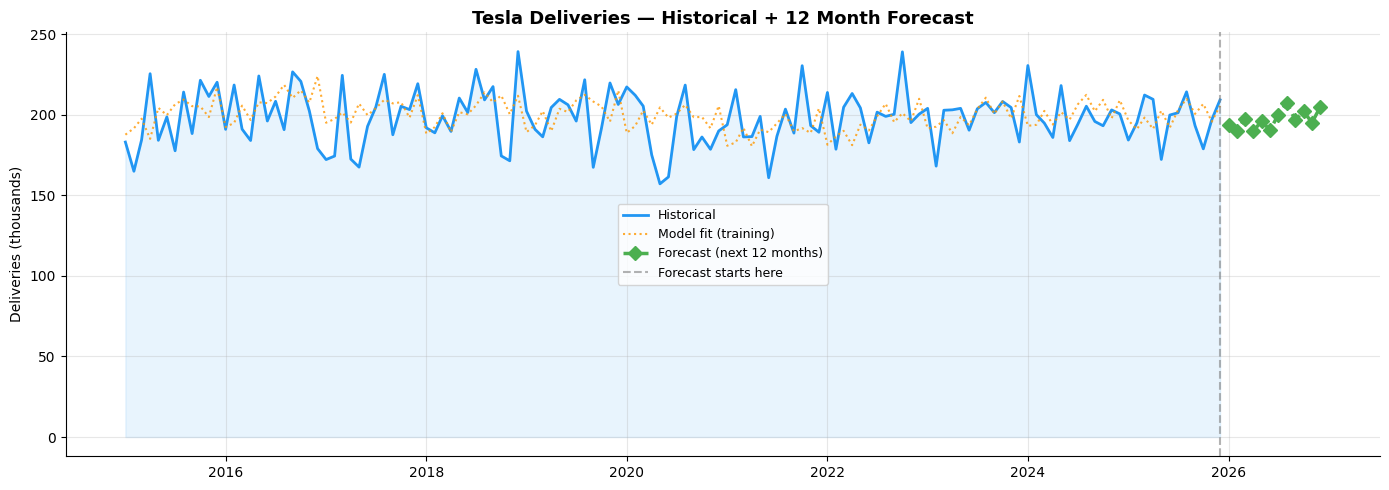

In [30]:
# Plot historical + forecast
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts.index, ts.values / 1000,
        color='#2196F3', linewidth=2, label='Historical')
ax.fill_between(ts.index, ts.values / 1000, alpha=0.1, color='#2196F3')

ax.plot(ts.index, ets_fit.fittedvalues / 1000,
        color='#FF9800', linewidth=1.5, linestyle=':', alpha=0.8,
        label='Model fit (training)')

ax.plot(future_dates, forecast.values / 1000,
        'D--', color='#4CAF50', linewidth=2.5, markersize=7,
        label='Forecast (next 12 months)')

ax.axvline(ts.index[-1], color='gray', linestyle='--',
           linewidth=1.5, alpha=0.6, label='Forecast starts here')

ax.set_title('Tesla Deliveries — Historical + 12 Month Forecast',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Deliveries (thousands)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 9 — Final Summary

In [32]:
print("=" * 55)
print("  TESLA ML PROJECT -- FINAL SUMMARY")
print("=" * 55)
print()
print(f'DATASET')
print(f'  Rows: {len(df_clean):,}  |  Columns: {df_clean.shape[1]}')
print(f'  Years: {df_clean["Year"].min()} to {df_clean["Year"].max()}')
print(f'  Regions: {len(df_clean["Region"].unique())} regions')
print(f'  Models:  {len(df_clean["Model"].unique())} models')
print()
print("DATA CLEANING")
print("  No missing values found")
print("  No duplicates found")
print("  Outlier check done with IQR method")
print()
print(f'FEATURES  ({len(feature_cols)} total)')
print("  + Encoded: Region, Model, Source_Type")
print("  + Created: Quarter, is_end_of_quarter, price_per_km")
print("  + Original numeric columns")
print()
print("MODEL RESULT")
print(f'  Linear Regression  R^2={r2:.4f}  MAE={mae:,.0f} cars')
print()
print("FORECASTING")
print("  Exponential Smoothing — 12 month forecast")
print("  Captures trend + seasonal monthly pattern")
print()
print("THINGS I WANT TO TRY NEXT")
print("  - Polynomial Regression (curved line)")
print("  - Add stock price as a feature")
print("  - Predict by region separately")
print("=" * 55)


  TESLA ML PROJECT -- FINAL SUMMARY

DATASET
  Rows: 2,640  |  Columns: 12
  Years: 2015 to 2025
  Regions: 4 regions
  Models:  5 models

DATA CLEANING
  No missing values found
  No duplicates found
  Outlier check done with IQR method

FEATURES  (14 total)
  + Encoded: Region, Model, Source_Type
  + Created: Quarter, is_end_of_quarter, price_per_km
  + Original numeric columns

MODEL RESULT
  Linear Regression  R^2=0.9901  MAE=310 cars

FORECASTING
  Exponential Smoothing — 12 month forecast
  Captures trend + seasonal monthly pattern

THINGS I WANT TO TRY NEXT
  - Polynomial Regression (curved line)
  - Add stock price as a feature
  - Predict by region separately
